# House Price Prediction - II
## Ames Housing Dataset
##### Link to dataset - https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset

### Step 1: Environment setup and imports

In [2]:
import platform
import json
import os
from datetime import datetime
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

SEED = 42
np.random.seed(SEED)

print(f"Python version: {platform.python_version()}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

print("Libraries imported successfully.")

Python version: 3.10.0
NumPy version: 2.2.6
Pandas version: 2.3.2
Matplotlib version: 3.10.6
Seaborn version: 0.13.2
Scikit-learn version: 1.7.2
Libraries imported successfully.


### Step 2: Load the Ames Housing Dataset

In [3]:
# Load the data
df = pd.read_csv('AmesHousing.csv')
print("Dataset shape:", df.shape)
print("\nData sample:\n", df.head(3))
print("\nColumns:", df.columns.tolist())

Dataset shape: (2930, 82)

Data sample:
    Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0        0       5    2010       WD           Normal     215000  
1        0       6    2010       WD           Normal     105000  
2    12500       6    2010       WD           Normal     172000  

[3 rows x 82 columns]

Columns: ['Order', 'PID', 'MS SubClass', 'MS Zoning',

### Step 3: Data and target audit

In [4]:
target = 'SalePrice'
print(f"\nData Audit:")
print(f"Target variable: {target}")
print(f"Target dtype: {df[target].dtype}")

audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_n': df.isna().sum(),
    'missing_%': df.isna().mean() * 100,
    'unique_n': df.nunique(dropna=False)
}).sort_values('missing_%', ascending=False)

print("\nData Audit (columns with missing values first):")
display(audit.head(20))

print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nTarget variable statistics:")
display(df[target].describe())


Data Audit:
Target variable: SalePrice
Target dtype: int64

Data Audit (columns with missing values first):


,dtype,missing_n,missing_%,unique_n
Pool QC,object,2917,99.556314,5
Misc Feature,object,2824,96.382253,6
Alley,object,2732,93.242321,3
Fence,object,2358,80.477816,5
Mas Vnr Type,object,1775,60.580205,5
Fireplace Qu,object,1422,48.532423,6
Lot Frontage,float64,490,16.723549,129
Garage Qual,object,159,5.426621,6
Garage Yr Blt,float64,159,5.426621,104
Garage Cond,object,159,5.426621,6


Duplicate rows: 0

Target variable statistics:


count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

### Step 4: Initial EDA (on training data only after split)

Training set shape: (2344, 79)
Test set shape: (586, 79)


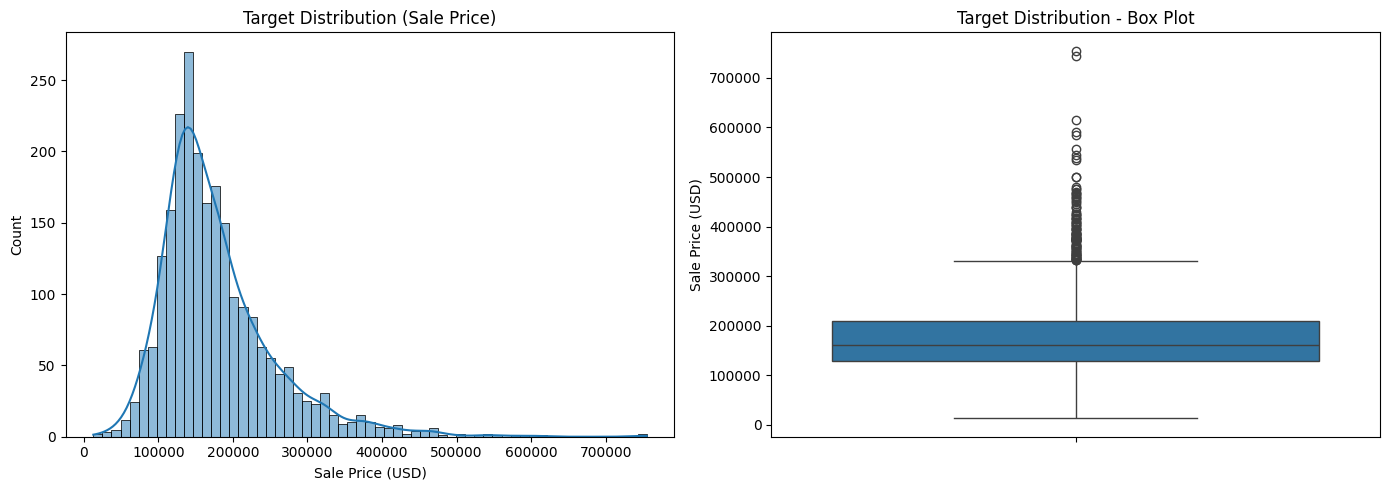

Target skewness: 1.751


In [5]:
# Drop non-predictive identifiers
DROP_COLS = ['Order', 'PID'] if 'Order' in df.columns else []
X = df.drop(columns=DROP_COLS + [target])
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

train_df = X_train.copy()
train_df[target] = y_train

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_df[target], kde=True, ax=axes[0])
axes[0].set_title('Target Distribution (Sale Price)')
axes[0].set_xlabel('Sale Price (USD)')
sns.boxplot(y=train_df[target], ax=axes[1])
axes[1].set_title('Target Distribution - Box Plot')
axes[1].set_ylabel('Sale Price (USD)')
plt.tight_layout()
plt.show()

print(f"Target skewness: {train_df[target].skew():.3f}")

### Step 5: Data preprocessing pipeline (leakage-safe)

In [6]:
# Separate numeric and categorical features
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# For numeric: median imputation + scaling
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For categorical: most frequent imputation + one-hot encoding
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
], remainder='drop')

# Test the preprocessor
X_transformed = preprocess.fit_transform(X_train)
print(f"Preprocessed training data shape: {X_transformed.shape}")
print(f"Number of features after preprocessing: {X_transformed.shape[1]}")

Numeric features: 36
Categorical features: 43
Preprocessed training data shape: (2344, 300)
Number of features after preprocessing: 300


### Step 6: Naive baseline

In [7]:
naive = DummyRegressor(strategy='mean')
naive.fit(X_train[numeric_features], y_train)
naive_pred = naive.predict(X_test[numeric_features])

naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
print(f"Naive (Mean) MAE: {naive_mae:.2f}")
print(f"Naive (Mean) RMSE: {naive_rmse:.2f}")

Naive (Mean) MAE: 64611.41
Naive (Mean) RMSE: 90222.37


### Step 7: Simple Linear Regression (using GrLivArea – living area)

Feature selected: Gr Liv Area
Intercept: 19250.56
Slope: 106.73
Interpretation: Each additional square foot of living area increases price by 106.73 USD


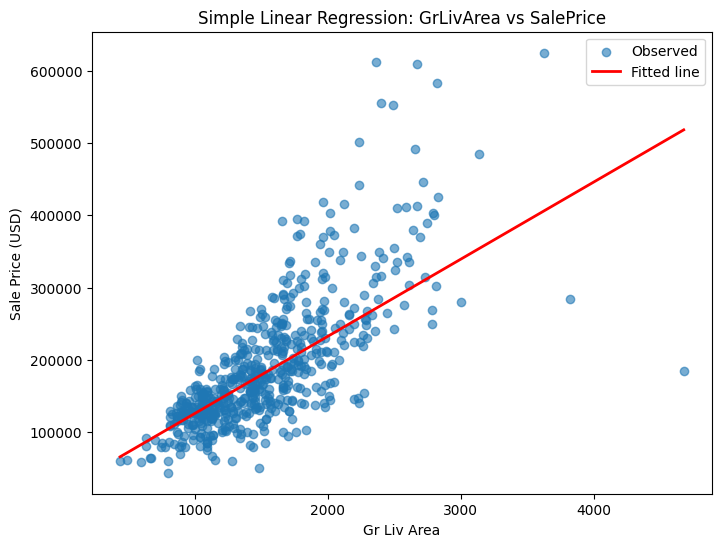

Simple Linear Regression Metrics:
MAE: 41365.51
RMSE: 61815.73
R²: 0.5234


In [9]:
simple_feature = 'Gr Liv Area'
simple_model = LinearRegression()
simple_model.fit(X_train[[simple_feature]], y_train)
simple_pred = simple_model.predict(X_test[[simple_feature]])

print(f"Feature selected: {simple_feature}")
print(f"Intercept: {simple_model.intercept_:.2f}")
print(f"Slope: {simple_model.coef_[0]:.2f}")
print(f"Interpretation: Each additional square foot of living area increases price by {simple_model.coef_[0]:.2f} USD")

# Plot
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(X_test[simple_feature], y_test, alpha=0.6, label='Observed')
order = np.argsort(X_test[simple_feature].to_numpy())
ax.plot(X_test[simple_feature].to_numpy()[order], simple_pred[order],
        linewidth=2, color='red', label='Fitted line')
ax.set_xlabel(simple_feature)
ax.set_ylabel('Sale Price (USD)')
ax.set_title('Simple Linear Regression: GrLivArea vs SalePrice')
ax.legend()
plt.show()

simple_mae = mean_absolute_error(y_test, simple_pred)
simple_rmse = np.sqrt(mean_squared_error(y_test, simple_pred))
simple_r2 = r2_score(y_test, simple_pred)
print(f"Simple Linear Regression Metrics:")
print(f"MAE: {simple_mae:.2f}")
print(f"RMSE: {simple_rmse:.2f}")
print(f"R²: {simple_r2:.4f}")

### Step 8: Multiple Linear Regression and other models

In [10]:
# Define model pipelines
model_pipelines = {
    'Linear Regression': Pipeline([('preprocess', preprocess), ('model', LinearRegression())]),
    'Ridge': Pipeline([('preprocess', preprocess), ('model', Ridge(alpha=1.0))]),
    'Lasso': Pipeline([('preprocess', preprocess), ('model', Lasso(alpha=0.001, max_iter=20000))]),
    'Elastic Net': Pipeline([('preprocess', preprocess), ('model', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000))]),
    'Decision Tree': Pipeline([('preprocess', preprocess), ('model', DecisionTreeRegressor(max_depth=6, random_state=SEED))]),
    'Random Forest': Pipeline([('preprocess', preprocess), ('model', RandomForestRegressor(n_estimators=200, min_samples_leaf=2, random_state=SEED, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('preprocess', preprocess), ('model', GradientBoostingRegressor(random_state=SEED))])
}

# Also XGBoost separately
xgb_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', XGBRegressor(n_estimators=200, learning_rate=0.03, max_depth=4,
                           subsample=0.8, colsample_bytree=0.8,
                           objective='reg:squarederror', random_state=SEED, n_jobs=-1))
])

# Fit all models and collect predictions
all_models = {}
predictions = {}
for name, pipe in model_pipelines.items():
    print(f"Fitting {name}...")
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    all_models[name] = pipe
    predictions[name] = pred

# Fit XGBoost
xgb_pipe.fit(X_train, y_train)
xgb_pred = xgb_pipe.predict(X_test)
all_models['XGBoost'] = xgb_pipe
predictions['XGBoost'] = xgb_pred

Fitting Linear Regression...
Fitting Ridge...
Fitting Lasso...


c:\Users\apara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.218e+11, tolerance: 1.394e+09
  model = cd_fast.enet_coordinate_descent(


Fitting Elastic Net...
Fitting Decision Tree...
Fitting Random Forest...
Fitting Gradient Boosting...


### Step 9: Evaluation function and results

In [11]:
def evaluate_regressor(name, model, X_eval, y_eval):
    pred = model.predict(X_eval)
    mae = mean_absolute_error(y_eval, pred)
    mse = mean_squared_error(y_eval, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_eval, pred)
    # MAPE
    mape = np.mean(np.abs((y_eval - pred) / y_eval)) * 100
    # Train metrics for overfitting check
    train_pred = model.predict(X_train)
    train_mae = mean_absolute_error(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    train_r2 = r2_score(y_train, train_pred)
    return {
        'Model': name,
        'Test_MAE': mae,
        'Test_RMSE': rmse,
        'Test_R2': r2,
        'MAPE_%': mape,
        'Train_MAE': train_mae,
        'Train_RMSE': train_rmse,
        'Train_R2': train_r2
    }

results = []
for name, model in all_models.items():
    res = evaluate_regressor(name, model, X_test, y_test)
    results.append(res)

eval_df = pd.DataFrame(results).sort_values('Test_RMSE')
print("\nMODEL PERFORMANCE SUMMARY (Sorted by RMSE)")
display(eval_df.round(2))


MODEL PERFORMANCE SUMMARY (Sorted by RMSE)


,Model,Test_MAE,Test_RMSE,Test_R2,MAPE_%,Train_MAE,Train_RMSE,Train_R2
7,XGBoost,15045.41,25100.92,0.92,8.04,10670.28,14818.71,0.96
6,Gradient Boosting,15165.20,25928.42,0.92,8.06,11235.03,15312.88,0.96
5,Random Forest,15729.69,26827.57,0.91,8.53,6510.45,11962.47,0.98
1,Ridge,16186.78,28896.36,0.90,8.77,13737.70,20470.24,0.93
3,Elastic Net,16243.90,28923.28,0.90,8.78,13794.94,20635.38,0.93
2,Lasso,15868.93,29253.40,0.89,9.18,13141.08,18986.06,0.94
0,Linear Regression,16007.38,29615.38,0.89,9.28,13125.11,18980.98,0.94
4,Decision Tree,22329.61,32284.94,0.87,12.59,17984.22,25324.26,0.89


### Step 10: Cross-validation (5-fold)

In [12]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}
cv_results_list = []
for name, pipe in all_models.items():
    print(f"Cross-validating {name}...")
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results_list.append({
        'Model': name,
        'CV_MAE_mean': -scores['test_mae'].mean(),
        'CV_MAE_std': scores['test_mae'].std(),
        'CV_RMSE_mean': -scores['test_rmse'].mean(),
        'CV_RMSE_std': scores['test_rmse'].std(),
        'CV_R2_mean': scores['test_r2'].mean(),
        'CV_R2_std': scores['test_r2'].std()
    })
cv_df = pd.DataFrame(cv_results_list).sort_values('CV_RMSE_mean')
print("\nCROSS-VALIDATION RESULTS (5-fold)")
display(cv_df.round(2))

Cross-validating Linear Regression...
Cross-validating Ridge...
Cross-validating Lasso...
Cross-validating Elastic Net...
Cross-validating Decision Tree...
Cross-validating Random Forest...
Cross-validating Gradient Boosting...
Cross-validating XGBoost...

CROSS-VALIDATION RESULTS (5-fold)


,Model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std
7,XGBoost,14915.10,1393.41,24277.95,5450.49,0.90,0.05
6,Gradient Boosting,15095.39,1503.63,24717.69,6328.71,0.89,0.06
5,Random Forest,16081.00,1484.47,26596.70,5812.55,0.88,0.05
2,Lasso,16351.75,1337.09,27951.15,9163.32,0.85,0.10
0,Linear Regression,16425.69,1355.66,28193.65,9482.06,0.85,0.11
3,Elastic Net,16571.96,1124.97,29034.87,8975.94,0.84,0.10
1,Ridge,16578.45,1118.58,29053.63,8973.10,0.84,0.10
4,Decision Tree,24353.90,1403.42,37968.25,4680.88,0.75,0.07


### Step 11: Hyperparameter tuning (XGBoost)

In [18]:
# Tune XGBoost
xgb_pipe_tune = Pipeline([
    ('preprocess', preprocess),
    ('model', XGBRegressor(objective='reg:squarederror', random_state=SEED, n_jobs=-1))
])
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.03, 0.1],
    'model__max_depth': [3, 4, 6],
    'model__subsample': [0.7, 0.8, 0.9]
}
grid_xgb = GridSearchCV(xgb_pipe_tune, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
print(f"Best parameters: {grid_xgb.best_params_}")
print(f"Best CV RMSE: {-grid_xgb.best_score_:.2f}")
xgb_tuned = grid_xgb.best_estimator_
xgb_tuned_pred = xgb_tuned.predict(X_test)
xgb_tuned_rmse = np.sqrt(mean_squared_error(y_test, xgb_tuned_pred))
xgb_tuned_r2 = r2_score(y_test, xgb_tuned_pred)
print(f"Tuned XGBoost Test RMSE: {xgb_tuned_rmse:.2f}")
print(f"Tuned XGBoost Test R2: {xgb_tuned_r2:.4f}")

Best parameters: {'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best CV RMSE: 23327.46
Tuned XGBoost Test RMSE: 24676.31
Tuned XGBoost Test R2: 0.9241


### Step 12: Final comparison including tuned models

In [19]:
# Add tuned model to evaluation
tuned_results = [
    {
        'Model': 'Tuned XGBoost',
        'Test_MAE': mean_absolute_error(y_test, rf_tuned_pred),
        'Test_RMSE': rf_tuned_rmse,
        'Test_R2': rf_tuned_r2,
        'MAPE_%': np.mean(np.abs((y_test - rf_tuned_pred) / y_test)) * 100,
        'Train_MAE': mean_absolute_error(y_train, rf_tuned.predict(X_train)),
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, rf_tuned.predict(X_train))),
        'Train_R2': r2_score(y_train, rf_tuned.predict(X_train))
    }
]

all_results = pd.concat([eval_df, pd.DataFrame(tuned_results)], ignore_index=True)
all_results = all_results.sort_values('Test_RMSE')
print("\nFINAL RESULTS WITH TUNED MODEL")
display(all_results.round(2))

best_model_name = all_results.iloc[0]['Model']
if best_model_name == 'Tuned XGBoost':
    best_model = xgb_tuned
else:
    best_model = all_models[best_model_name]
    
print(f"Best Overall Model: {best_model_name}")
print(f"  Test RMSE: {all_results.iloc[0]['Test_RMSE']:.2f}")
print(f"  Test R²: {all_results.iloc[0]['Test_R2']:.4f}")


FINAL RESULTS WITH TUNED MODEL


,Model,Test_MAE,Test_RMSE,Test_R2,MAPE_%,Train_MAE,Train_RMSE,Train_R2
0,XGBoost,15045.41,25100.92,0.92,8.04,10670.28,14818.71,0.96
1,Gradient Boosting,15165.20,25928.42,0.92,8.06,11235.03,15312.88,0.96
2,Random Forest,15729.69,26827.57,0.91,8.53,6510.45,11962.47,0.98
8,Tuned XGBoost,15757.57,26925.08,0.91,8.51,6101.71,9993.93,0.98
3,Ridge,16186.78,28896.36,0.90,8.77,13737.70,20470.24,0.93
4,Elastic Net,16243.90,28923.28,0.90,8.78,13794.94,20635.38,0.93
5,Lasso,15868.93,29253.40,0.89,9.18,13141.08,18986.06,0.94
6,Linear Regression,16007.38,29615.38,0.89,9.28,13125.11,18980.98,0.94
7,Decision Tree,22329.61,32284.94,0.87,12.59,17984.22,25324.26,0.89


Best Overall Model: XGBoost
  Test RMSE: 25100.92
  Test R²: 0.9214


### Step 13: Residual diagnostics for linear and best model

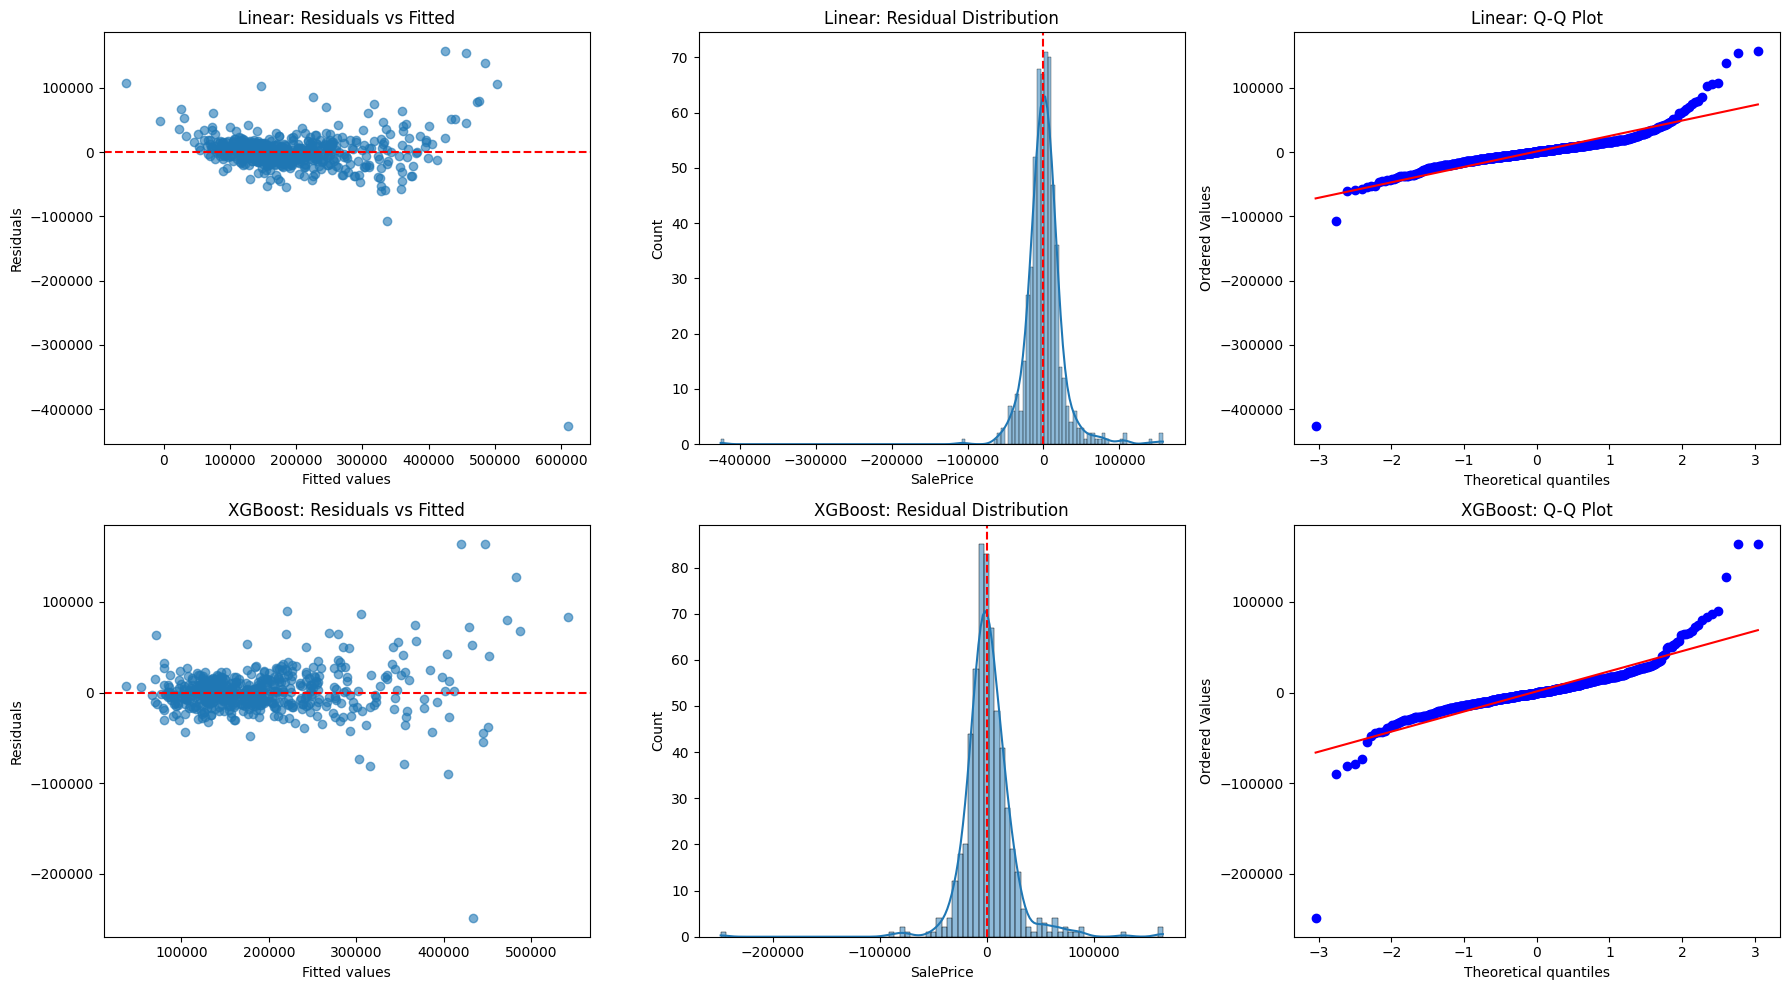

In [15]:
# Linear model
linear_model = all_models['Linear Regression']
linear_pred = linear_model.predict(X_test)
linear_resid = y_test - linear_pred

# Best model
best_pred = best_model.predict(X_test)
best_resid = y_test - best_pred

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Linear residuals vs fitted
axes[0,0].scatter(linear_pred, linear_resid, alpha=0.6)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel('Fitted values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Linear: Residuals vs Fitted')

# Linear residual distribution
sns.histplot(linear_resid, kde=True, ax=axes[0,1])
axes[0,1].axvline(0, color='red', linestyle='--')
axes[0,1].set_title('Linear: Residual Distribution')

# Linear Q-Q
import scipy.stats as stats
stats.probplot(linear_resid, dist="norm", plot=axes[0,2])
axes[0,2].set_title('Linear: Q-Q Plot')

# Best model residuals vs fitted
axes[1,0].scatter(best_pred, best_resid, alpha=0.6)
axes[1,0].axhline(0, color='red', linestyle='--')
axes[1,0].set_xlabel('Fitted values')
axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title(f'{best_model_name}: Residuals vs Fitted')

sns.histplot(best_resid, kde=True, ax=axes[1,1])
axes[1,1].axvline(0, color='red', linestyle='--')
axes[1,1].set_title(f'{best_model_name}: Residual Distribution')

stats.probplot(best_resid, dist="norm", plot=axes[1,2])
axes[1,2].set_title(f'{best_model_name}: Q-Q Plot')

plt.tight_layout()
plt.show()

### Step 14: Coefficient inspection (Linear Regression)

In [16]:
linear_fitted = all_models['Linear Regression']
feature_names = linear_fitted.named_steps['preprocess'].get_feature_names_out()
coefficients = linear_fitted.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'AbsCoefficient': np.abs(coefficients)
}).sort_values('AbsCoefficient', ascending=False)

print(f"\nIntercept: {linear_fitted.named_steps['model'].intercept_:.2f}")
print("Top 20 most influential features (by absolute coefficient):")
display(coef_df.head(20))


Intercept: -137870.37
Top 20 most influential features (by absolute coefficient):


,Feature,Coefficient,AbsCoefficient
130,cat__Roof Matl_ClyTile,-579647.009103,579647.009103
280,cat__Misc Feature_Elev,-408579.037745,408579.037745
282,cat__Misc Feature_Othr,151359.520151,151359.520151
8,num__BsmtFin SF 1,146437.480094,146437.480094
10,num__Bsmt Unf SF,131637.028048,131637.028048
281,cat__Misc Feature_Gar2,128972.540720,128972.540720
283,cat__Misc Feature_Shed,128246.976874,128246.976874
132,cat__Roof Matl_Membran,125579.549690,125579.549690
11,num__Total Bsmt SF,-123698.221683,123698.221683
137,cat__Roof Matl_WdShngl,109986.248966,109986.248966


### Step 15: Feature importance from XGBoost(Best model)

Top 20 feature importances from XGBoost:


,Feature,Importance
3,num__Overall Qual,0.201544
25,num__Garage Cars,0.118350
177,cat__Exter Qual_TA,0.040514
258,cat__Garage Finish_Unf,0.039437
189,cat__Bsmt Qual_Ex,0.037575
176,cat__Exter Qual_Gd,0.032931
18,num__Full Bath,0.028752
235,cat__Kitchen Qual_Gd,0.027177
174,cat__Exter Qual_Ex,0.026397
233,cat__Kitchen Qual_Ex,0.025773


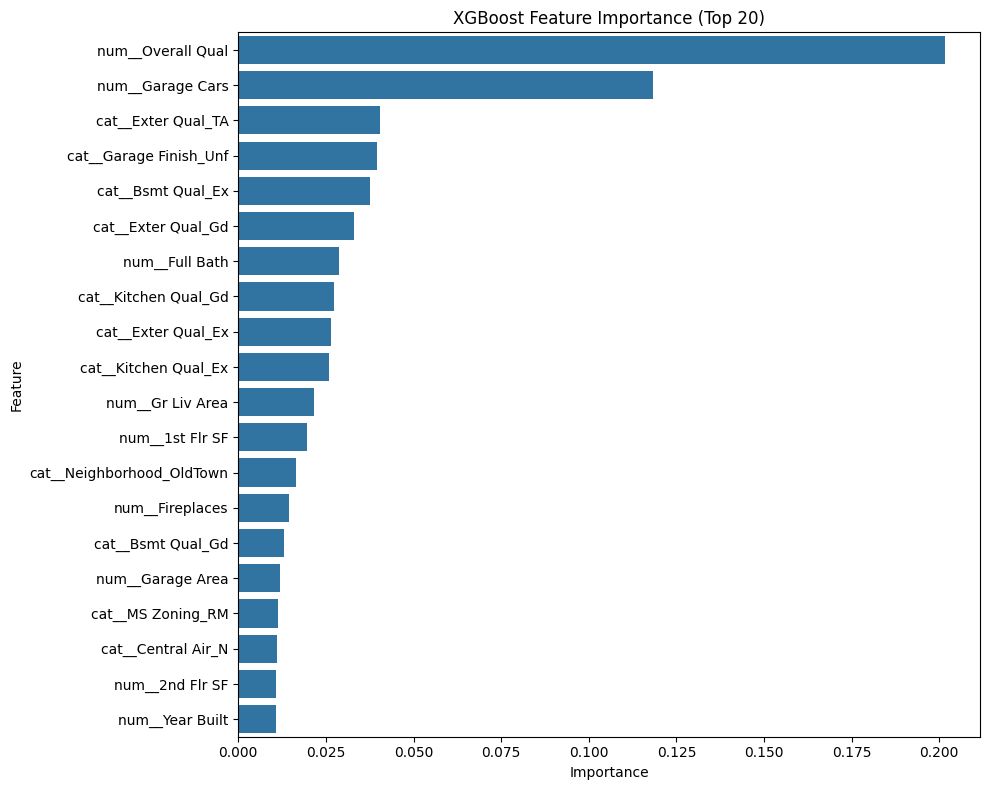

In [20]:
# Since the best model is XGBoost, extract and plot feature importance
if 'XGBoost' in best_model_name:
    xgb_model = best_model.named_steps['model']
    # Get feature names from preprocessor
    feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
    importances = xgb_model.feature_importances_
    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    print("Top 20 feature importances from XGBoost:")
    display(fi_df.head(20))
    
    # Plot
    plt.figure(figsize=(10,8))
    sns.barplot(data=fi_df.head(20), y='Feature', x='Importance')
    plt.title('XGBoost Feature Importance (Top 20)')
    plt.tight_layout()
    plt.show()
else:
    # Fallback: if for some reason best model is not XGBoost, provide generic message
    print("Best model is not XGBoost; feature importance not available in this block.")

### Step 16: Save artifacts and results

In [21]:
os.makedirs('artifacts', exist_ok=True)

# Save results
all_results.to_csv('artifacts/ames_all_results.csv', index=False)
cv_df.to_csv('artifacts/ames_cv_results.csv', index=False)

# Save the best model
joblib.dump(best_model, 'artifacts/ames_best_model.joblib')
print("Best model saved as 'artifacts/ames_best_model.joblib'")

# Save preprocessing pipeline
joblib.dump(preprocess, 'artifacts/ames_preprocessor.joblib')

# Save metadata
metadata = {
    'dataset': 'Ames Housing',
    'target': target,
    'train_shape': X_train.shape,
    'test_shape': X_test.shape,
    'best_model': best_model_name,
    'best_metrics': {
        'RMSE': float(all_results.iloc[0]['Test_RMSE']),
        'R2': float(all_results.iloc[0]['Test_R2']),
        'MAE': float(all_results.iloc[0]['Test_MAE'])
    },
    'random_seed': SEED
}
with open('artifacts/ames_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("Metadata saved.")

Best model saved as 'artifacts/ames_best_model.joblib'
Metadata saved.
